# CosMx Tutorial

This tutorial walks through a full **Renoir** workflow for analyzing cell-cell communication in a CosMx Spatial Molecular Imager (SMI) dataset of hepatocellular carcinoma (HCC). By the end, you will have:

1. Computed **neighborhood communication scores** at single-cell resolution.
2. Visualized **ligand–target activity** spatially across tissue fields of view (FOVs).
3. Built **pathway-level** and **de novo** ligand–target clusters.
4. Identified **communication domains** via Leiden clustering on the score matrix.
5. Run **differential expression** between domains and a **ligand-ranking** analysis to find drivers of a domain of interest.

---

## Contents

1. [Setup and imports](#1-setup-and-imports)
2. [Compute neighborhood scores](#2-compute-neighborhood-scores)
3. [Inspect and clean the score object](#3-inspect-and-clean-the-score-object)
4. [Spatial visualization of ligand–target activity](#4-spatial-visualization-of-ligandtarget-activity)
5. [Build pathway and de novo ligand–target clusters](#5-build-pathway-and-de-novo-ligandtarget-clusters)
6. [Identify communication domains](#6-identify-communication-domains)
7. [Visualize domains and pathway activity](#7-visualize-domains-and-pathway-activity)
8. [Differential expression between domains](#8-differential-expression-between-domains)
9. [Pathway activity in space](#9-pathway-activity-in-space)
10. [Ligand ranking analysis](#10-ligand-ranking-analysis)


> Data required to run this tutorial can be found here.


## 1. Setup and imports


In [1]:
import Renoir
import scanpy as sc
import squidpy as sq
import pandas as pd
import pickle as pkl


## 2. Compute neighborhood scores

### Key arguments

| Argument | What it is |
|---|---|
| `SC_path`, `ST_path` | Path to the single-cell / spatial AnnData (`.h5ad`). For CosMx single-cell mode both can point to the same file. |
| `pairs_path` | CSV of pre-selected top ligand–target pairs (here, the top 100 ordered by joint optimization). |
| `ligand_receptor_path` | Curated ligand–receptor pair table (e.g., from NATMI / OmniPath). |
| `celltype_proportions_path` | Per-cell (or per-spot) cell-type proportions. |
| `expins_path` | Precomputed neighborhood-expression pickle — speeds things up substantially on large datasets. |
| `single_cell=True` | Run in single-cell mode (vs. spot-level for Visium-like data). |
| `radius=198` | Neighborhood radius **in the same units as the spatial coordinates** (microns for CosMx). 198 μm is a reasonable mid-range for HCC tissue. |

The call returns an **AnnData** whose `.X` is the cell × ligand-target score matrix.

> **Caution:** this step is expensive on full datasets (> 500000 spots with > 10000 genes). Expect a few minutes to tens of minutes depending on cell count and pair count.

In [2]:
neighborhood_scores = Renoir.compute_neighborhood_scores(
    SC_path='/path/to/cell_level.h5ad',
    ST_path='/path/to/cell_level.h5ad',
    pairs_path='/path/to/top_100_target_opt_both_ordered.csv',
    ligand_receptor_path='/path/to/All_human_lrpairs.csv',
    celltype_proportions_path='/path/to/celltype_prop_cell_level.csv',
    expins_path='/path/to/mRNA_subset_cell_level.pkl',
    single_cell=True,
    radius=198,
)


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/renoir.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_sc = mean_sc.groupby('celltype').mean().T.to_dict()
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/renoir.py:276: RuntimeWarning: invalid value encountered in divide
  PEM = np.log10(expins/E)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/renoir.py:276: RuntimeWarning: divide by zero encountered in log10
  PEM = np.log10(expins/E)


## 3. Inspect and clean the score object

You should see roughly *N cells × N ligand-target pairs* and the standard CosMx `.obs` fields.


In [3]:
neighborhood_scores


AnnData object with n_obs × n_vars = 70166 × 5424
    obs: 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.CD298', 'Max.CD298', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'dualfiles', 'Run_name', 'Slide_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'Diversity', 'totalcounts', 'log10totalcounts', 'background', 'remove_flagged_cells', 'IFcolor', 'L1', 'L2', 'OF', 'array_row', 'array_col', 'celltype'
    var: 'gene_ids'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_fov'

In [4]:
#The fix below is purely cosmetic — it doesn't change any scores — but it prevents downstream plotting errors. Skip it if your data already has the right dtypes.

# Coerce `fov` to a categorical string so squidpy can use it as a library key
neighborhood_scores.obs['fov'] = neighborhood_scores.obs['fov'].astype('str')
neighborhood_scores.obs['fov'] = neighborhood_scores.obs['fov'].astype('category')

# `cell_ID` originally looks like 'c_1_10_42' — we just want the trailing integer (42)
# so it lines up with the segmentation mask labels squidpy reads.
neighborhood_scores.obs['cell_ID'] = [int(x.split('_')[3]) for x in neighborhood_scores.obs['cell_ID']]


## 4. Spatial visualization of ligand–target activity

With scores in hand, the simplest exploratory view is a spatial map of one ligand–target pair, painted onto the cell segmentation. Below we plot **`IL6:PTGS2`** across FOVs 10, 11, and 12.


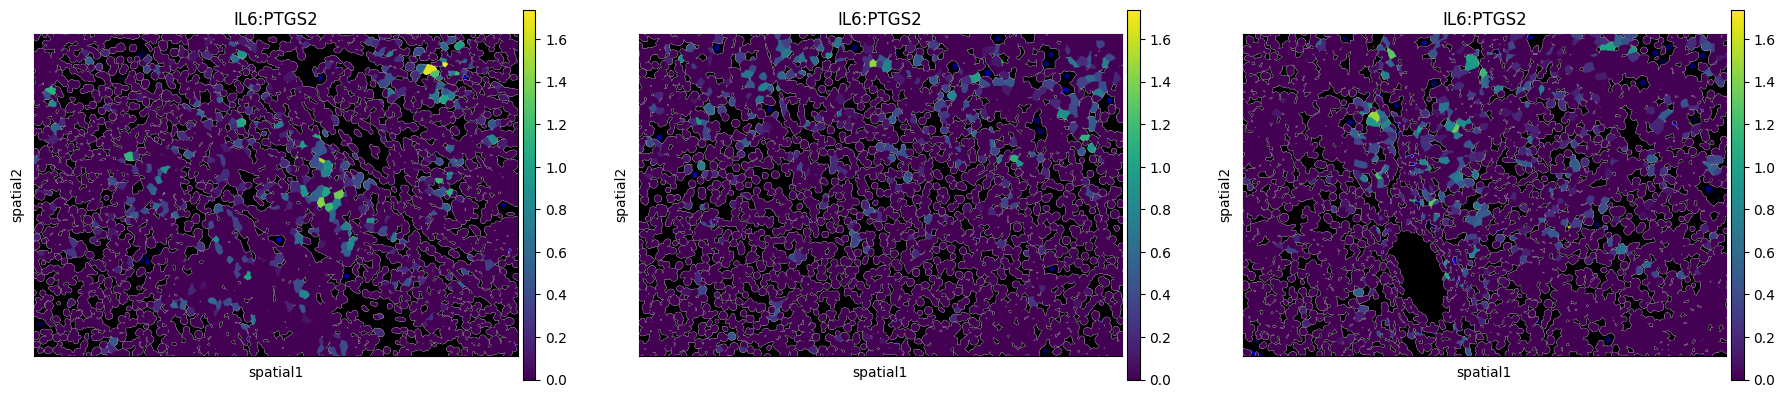

In [5]:
sq.pl.spatial_segment(
    neighborhood_scores,
    color='IL6:PTGS2',
    library_key="fov",
    library_id=['10', '11', '12'],
    seg_cell_id="cell_ID",
)


## 5. Build pathway and de novo ligand–target clusters

Renoir lets you group ligand–target pairs into **clusters** so you can score whole biological programs at once. Two flavors are supported:

- **Pathway-based clusters** — using a curated gene-set database (e.g., MSigDB Hallmark, KEGG, WikiPathways). Each pathway becomes a cluster of all ligand–target pairs whose target gene is in that set.
- **De novo clusters** — discovered directly from the score matrix (no prior knowledge required but expensive).

In [10]:
# Load curated MSigDB pathways (Hallmark + KEGG + WikiPathways, human)
msigh = Renoir.get_msig('custom', path='/shared/nr57/Renoir_data/msig_human_WP_H_KEGG_new.csv')

# Build one ligand-target cluster per pathway
pathways = Renoir.create_cluster(
    neighborhood_scores,
    msigh,
    method=None,          # pathway-based only; set 'leiden' (etc.) to also get de novo clusters
    restrict_to_KHW=True, # keep only KEGG / Hallmark / WikiPathways
)

# Peek at the available pathway names
pathways.keys()


dict_keys(['HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_APICAL_JUNCTION', 'HALLMARK_APOPTOSIS', 'HALLMARK_COAGULATION', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_IL2_STAT5_SIGNALING', 'HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK_INFLAMMATORY_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_KRAS_SIGNALING_UP', 'HALLMARK_TNFA_SIGNALING_VIA_NFKB', 'KEGG_ALLOGRAFT_REJECTION', 'KEGG_APOPTOSIS', 'KEGG_AUTOIMMUNE_THYROID_DISEASE', 'KEGG_BLADDER_CANCER', 'KEGG_CHEMOKINE_SIGNALING_PATHWAY', 'KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION', 'KEGG_CYTOSOLIC_DNA_SENSING_PATHWAY', 'KEGG_ERBB_SIGNALING_PATHWAY', 'KEGG_FOCAL_ADHESION', 'KEGG_GAP_JUNCTION', 'KEGG_GLIOMA', 'KEGG_GRAFT_VERSUS_HOST_DISEASE', 'KEGG_HEMATOPOIETIC_CELL_LINEAGE', 'KEGG_INTESTINAL_IMMUNE_NETWORK_FOR_IGA_PRODUCTION', 'KEGG_JAK_STAT_SIGNALING_PATHWAY', 'KEGG_MAPK_SIGNALING_PATHWAY', 'KEGG_MELANOMA', 'KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY', 'KEGG_PANCREATIC_CANCER', 'KEGG_PATHWAYS_IN_CANCER', 'KEGG_PROSTATE

## 6. Identify communication domains

`downstream_analysis` returns:

- `neighbscore_copy` — a copy of the AnnData with `obs['leiden']` populated (one label per cell = its domain).
- `pcs` — an AnnData of per-pathway activity scores (used in section 9 below).

### Tuning knobs
- **`resolution=0.1`** — Leiden resolution. Lower → fewer, broader domains; higher → more, finer ones.
- **`n_markers=20`** / **`n_top=20`** — number of top marker pairs per cluster to retain for downstream interpretation.
- **`pdf_path=None`** — set to a filepath to dump diagnostic plots to PDF.


In [11]:
neighbscore_copy, pcs = Renoir.downstream_analysis(
    neighborhood_scores,
    ltpair_clusters=pathways,
    resolution=0.1,
    n_markers=20,
    n_top=20,
    pdf_path=None,
    return_cluster=True,
    return_pcs=True,
)


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:182: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pcs = pcs.applymap(abs)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:227: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to w

## 7. Visualize domains and pathway activity


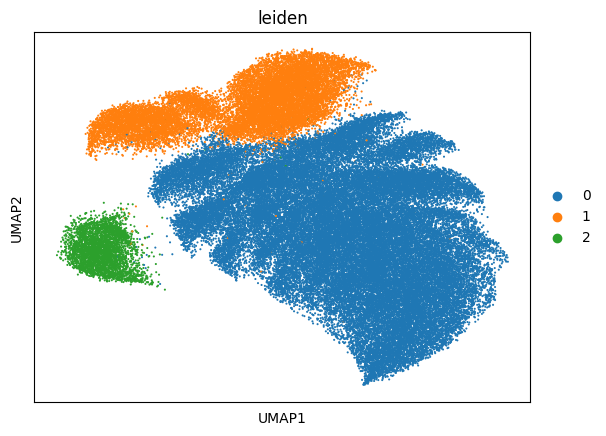

/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to

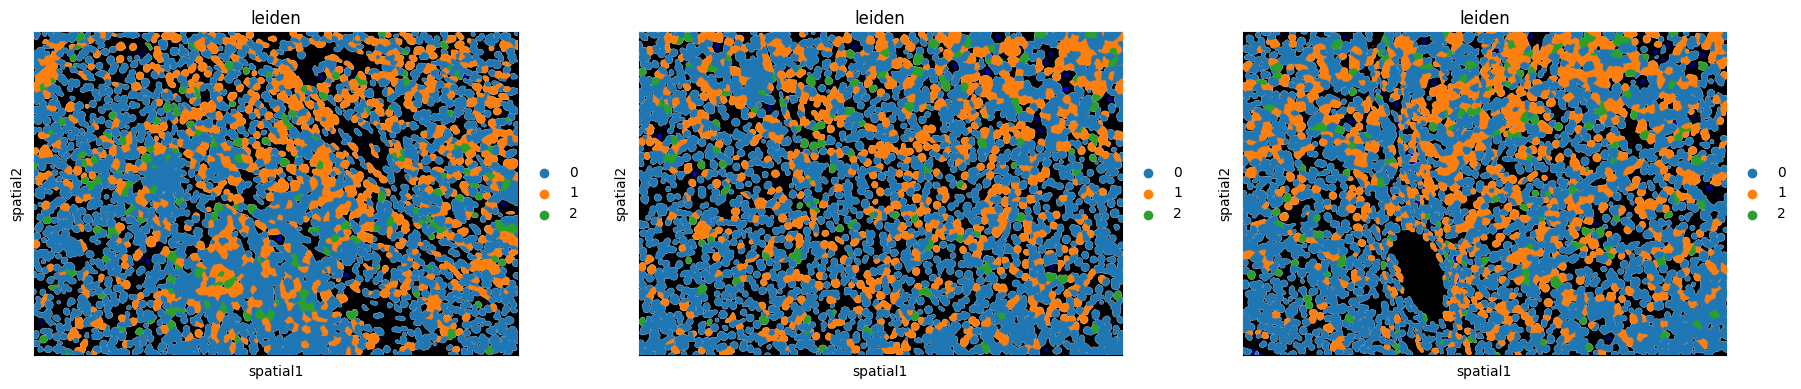

In [12]:
# UMAP colored by communication-domain assignment
sc.pl.umap(neighbscore_copy, components='all', color='leiden', size=9)

# The same domain labels mapped back onto the tissue
sq.pl.spatial_segment(
    neighborhood_scores,
    color='leiden',
    library_key="fov",
    library_id=['10', '11', '12'],
    seg_cell_id="cell_ID",
)


## 8. Differential expression between domains



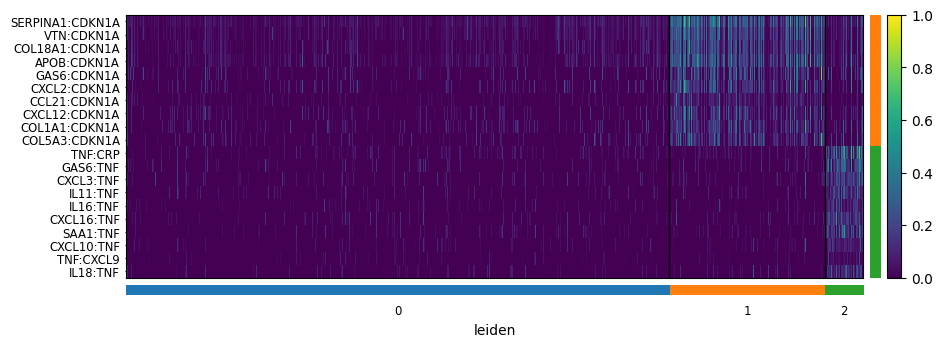

In [13]:
# Carry the domain labels back to the original score AnnData
neighborhood_scores.obs['leiden'] = neighbscore_copy.obs['leiden']
neighborhood_scores.uns = neighbscore_copy.uns

# One-vs-rest Wilcoxon ranking of ligand-target pairs per domain
sc.tl.rank_genes_groups(neighborhood_scores, "leiden", method="wilcoxon")

# Heatmap of the top-10 pairs per domain
sc.pl.rank_genes_groups_heatmap(
    neighborhood_scores,
    n_genes=10,
    groupby="leiden",
    show_gene_labels=True,
    min_logfoldchange=0.5,
    dendrogram=False,
    swap_axes=True,
    standard_scale='var',
    cmap='viridis',
)


## 9. Pathway activity in space

The `pcs` AnnData returned earlier holds a **per-cell activity score for every pathway cluster**. Painting one of these onto the tissue is often more interpretable than a single ligand–target pair, because it summarizes a whole biological program.

Below we visualize `HALLMARK_IL6_JAK_STAT3_SIGNALING` — a canonical inflammatory pathway and the larger context for the `IL6:PTGS2` pair we plotted earlier. Bright regions = areas where IL6/JAK/STAT3 signaling activity is predicted from the neighborhood.


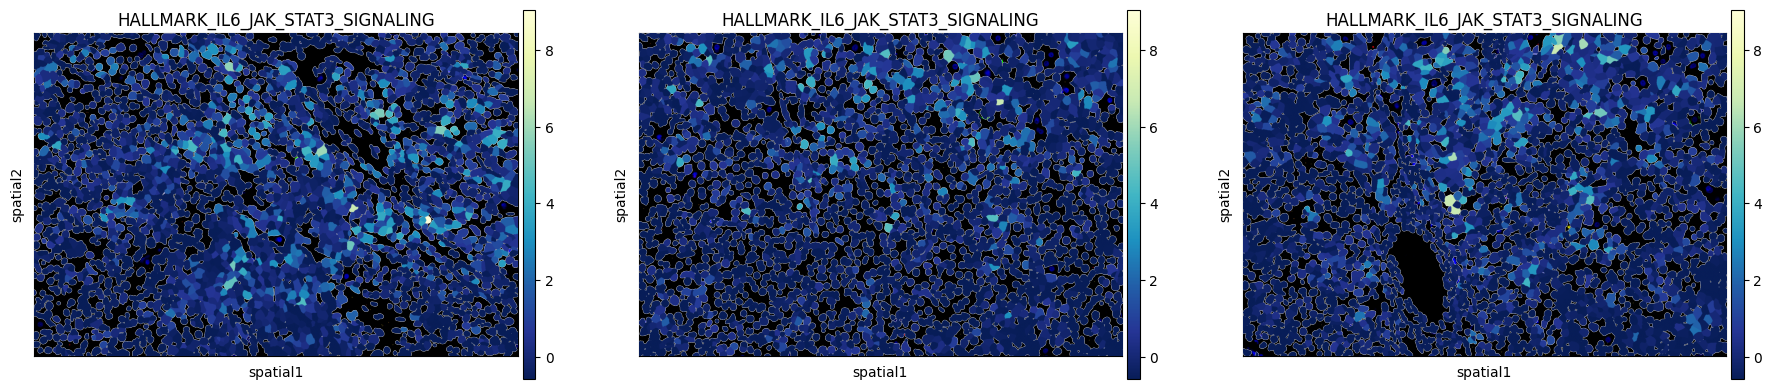

In [15]:
sq.pl.spatial_segment(
    pcs,
    color='HALLMARK_IL6_JAK_STAT3_SIGNALING',
    library_key="fov",
    library_id=['10', '11', '12'],
    seg_cell_id="cell_ID",
    cmap='YlGnBu_r',
)


## 10. Ligand ranking analysis


### Inputs needed
- `celltype` — AnnData with cell-type annotations (used to know which cell types are in the domain).
- `ligand_receptor_pairs` — curated L–R table (here, from NATMI).
- `ligand_target_regulatory_potential` — a precomputed pickle of ligand → top-500 target regulatory scores.
- The original single-cell AnnData `SC` — for measuring receptor expression.



In [28]:
# Load the supporting tables for ligand ranking
celltype = sc.read_h5ad('/shared/nr57/cosMX/HCC/celltype.h5ad')
ligand_receptor_pairs = pd.read_csv('/home/nr57/NATMI_ligand_receptor_pairs.csv')
ligand_target_regulatory_potential = pkl.load(
    open('/home/nr57/top_500_target_opt_both_scores.pkl', 'rb')
)
SC = sc.read_h5ad('/shared/nr57/cosMX/HCC/cell_level.h5ad')

# Stash the current score matrix so ligand_ranking can reach the raw values
neighborhood_scores.raw = neighborhood_scores.copy()


arguments below:

- `'1'` — rank ligands for **communication domain 1** (change to whichever domain you're investigating).
- `receptor_exp=0.05` — keep only ligands whose **receptor is expressed in at least 5%** of cells in the domain. Filters out ligands the domain literally can't sense.
- `markers={'top': 100}` — use the top 100 marker ligand–target pairs of the domain to score each ligand.
- `domain_celltypes=['top', 5]` — restrict the analysis to the **top 5 cell types** by abundance in the domain.

The output is a multi-panel figure: ligand ranking, expressing cell types, and the spatial location of the domain.


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:881: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.06160303276468995' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ct_bar_plot.loc[row,col] = celltype_avg[domain][col]
/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:881: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.06248307608989981' has dtype incompatible with int64, please expl

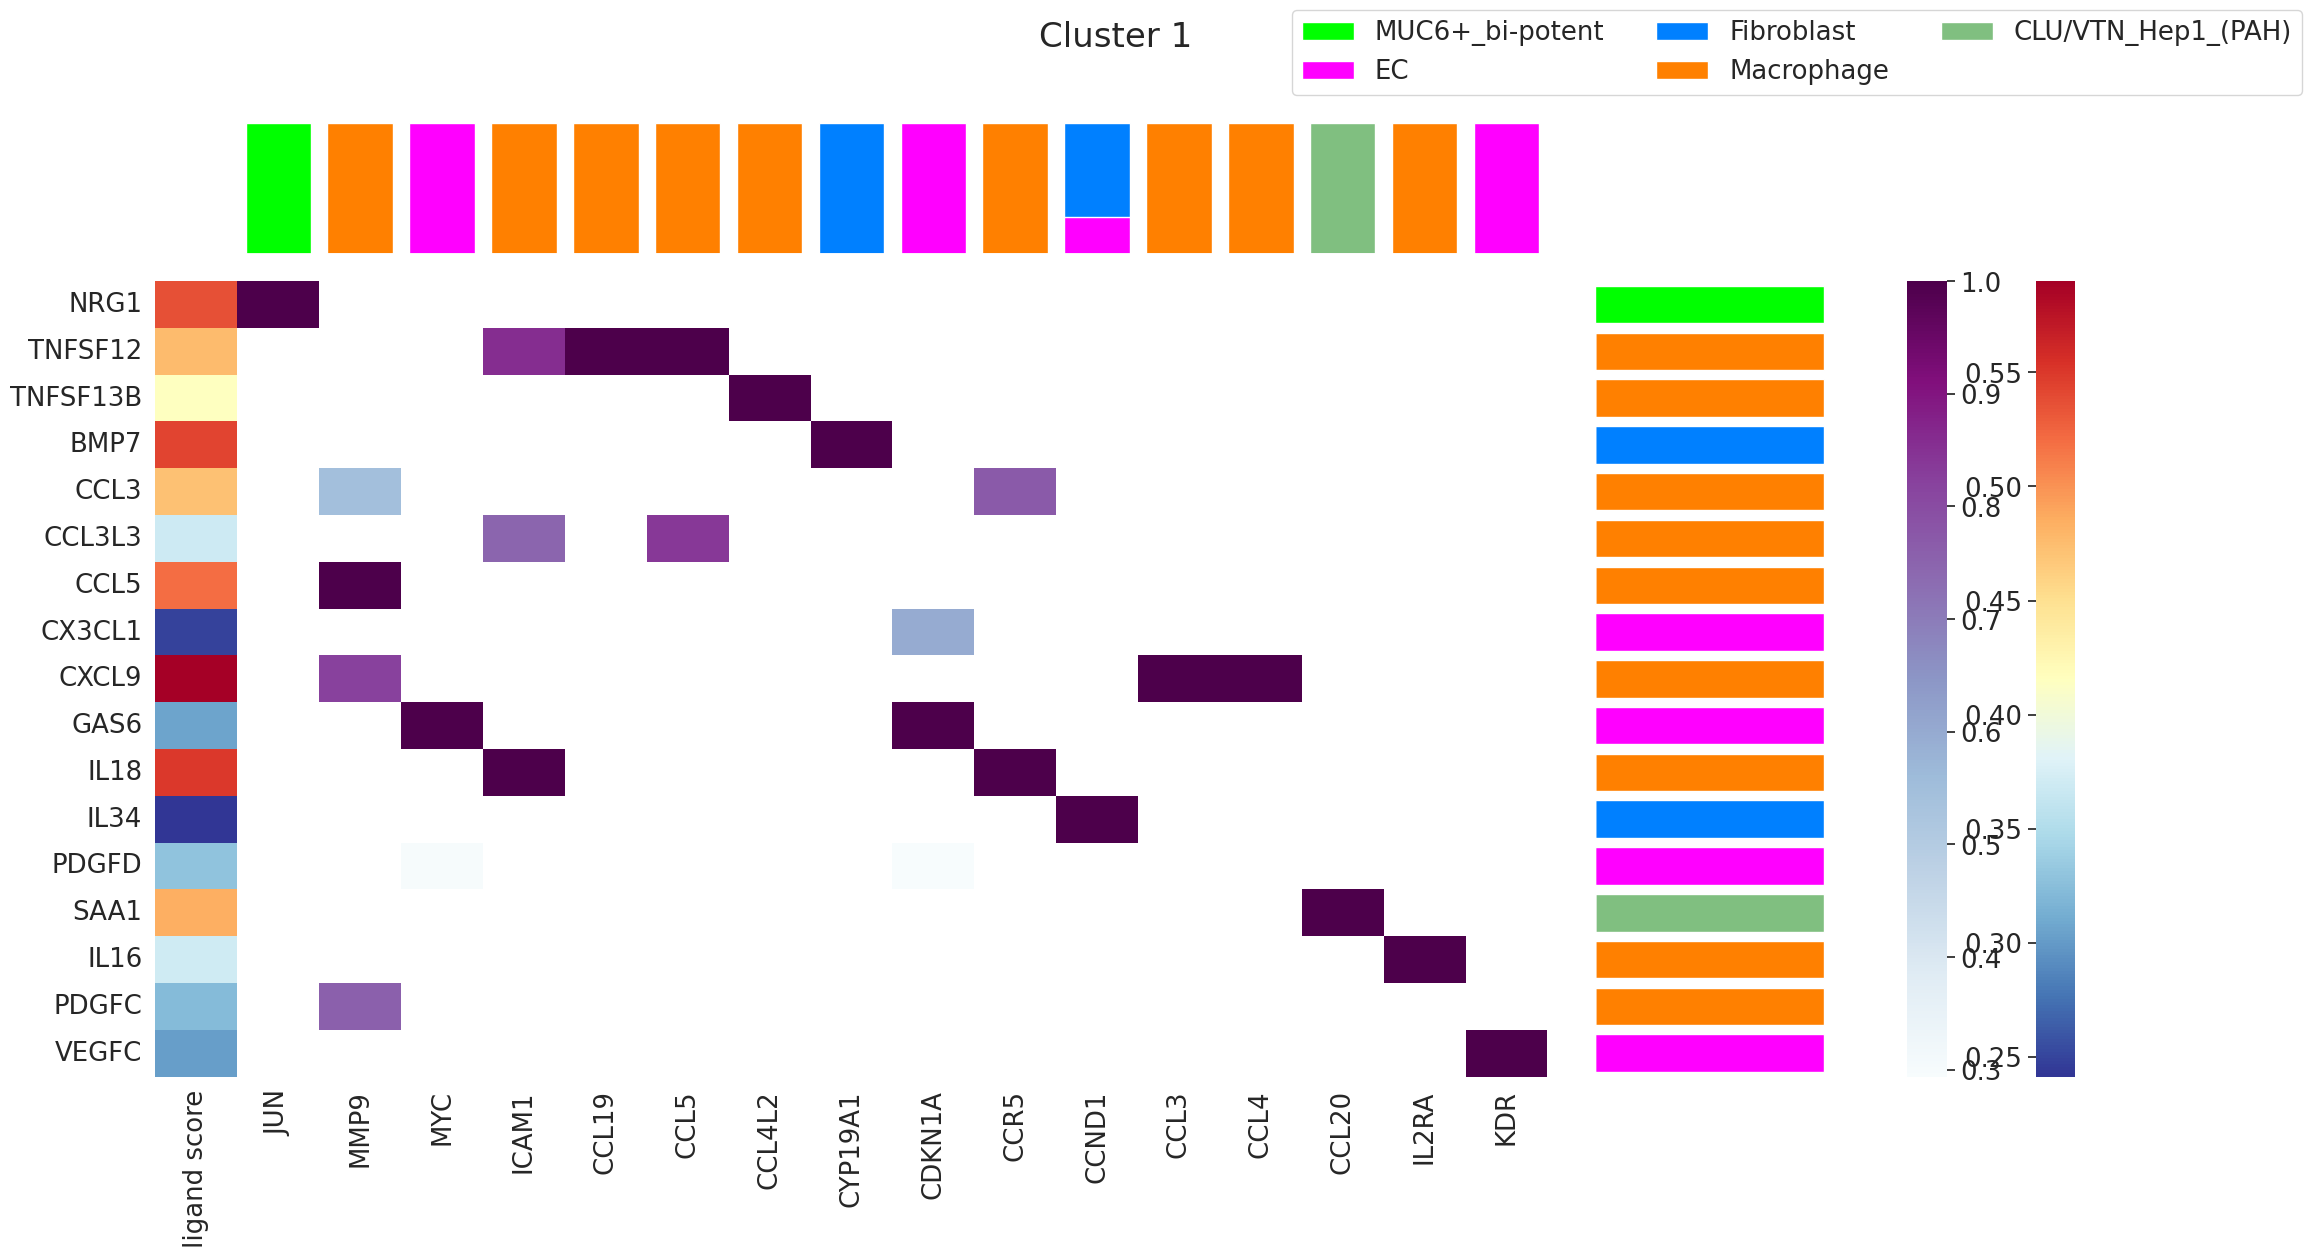

In [29]:
fig = Renoir.ligand_ranking(
    neighborhood_scores,
    celltype,
    SC,
    ligand_receptor_pairs,
    ligand_target_regulatory_potential,
    '1',                        # target domain ID
    receptor_exp=0.05,          # min receptor-expressing fraction
    markers={'top': 100},       # top-100 marker pairs as the ranking signal
    domain_celltypes=['top', 5],# restrict to top-5 cell types in the domain
)
fig.set_size_inches(24, 12)
fig
